# rf_shap demo（逐步可视化）

对应 `examples/run_demo.py`：用合成 CMIP6 风格立方体走完数据 → 特征 → 划分/采样 → 建模 → 预测 → 解释。
每一步都画图，便于检查对齐、泄漏和 SHAP 空间结构。

在仓库根目录启动 Jupyter，保证能 import `rf_shap`：

```bash
cd /path/to/rf_shap
PYTHONPATH=src jupyter notebook examples/run_demo.ipynb
```

In [2]:
from pathlib import Path
import sys

root = Path.cwd().resolve()
if (root / "src" / "rf_shap").exists():
    sys.path.insert(0, str(root / "src"))
elif (root.parent / "src" / "rf_shap").exists():
    sys.path.insert(0, str(root.parent / "src"))

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from rf_shap.config import PipelineConfig
from rf_shap.cube.features import build_x_features
from rf_shap.cube.preprocess import preprocess_dataset
from rf_shap.cube.tabular import cube_to_table
from rf_shap.explain.ale import ale_1d
from rf_shap.explain.ice_pdp import ice_pdp
from rf_shap.explain.importance import model_importance, permutation_scores
from rf_shap.explain.shap_explain import compute_shap, shap_to_cube
from rf_shap.features.select import select_features
from rf_shap.models.registry import build_model
from rf_shap.models.sampling import sample_train
from rf_shap.models.split import split_table
from rf_shap.plot import (
    plot_ale,
    plot_correlation,
    plot_cube_maps,
    plot_error_map,
    plot_histograms,
    plot_ice_pdp,
    plot_importance_bars,
    plot_pred_scatter,
    plot_sampling_map,
    plot_shap_maps,
    plot_shap_summary,
    plot_spatial_mean_timeseries,
    plot_split_coverage,
    plot_split_time,
)
from rf_shap.predict.metrics import regression_metrics
from rf_shap.predict.reconstruct import reconstruct_prediction
from rf_shap.synthetic import make_synthetic_cubes

In [1]:
# import shap
# import numpy
# import matplotlib.pyplot as plt

In [3]:
# pip install "shap==0.44.1" "numpy==1.23.5" "pandas==1.5.3" "matplotlib==3.6.3"

## 0. 配置（与 `run_demo.py` 一致）

In [4]:
SEED = 7
cfg = PipelineConfig.from_dict(
    {
        "seed": SEED,
        "x_transform": {"mode": "lag", "lags": [1]},
        "preprocess": {
            "x": {"deseasonalize": False, "detrend": False},
            "y": {"deseasonalize": False, "detrend": False},
        },
        "feature_selection": {
            "methods": ["collinearity", "pairwise_importance"],
            "collinearity": {
                "corr_threshold": 0.98,
                "vif_threshold": 20.0,
                "linreg_r2_threshold": 0.99,
            },
            "pairwise_importance": {"corr_threshold": 0.95},
        },
        "split": {"method": "time", "test_size": 0.25},
        "sampling": {"method": "fscs", "n_samples": 400},
        "model": {
            "name": "extra_trees",
            "params": {"n_estimators": 80, "max_depth": 8, "n_jobs": -1, "random_state": SEED},
        },
        "explain": {
            "permutation_n_repeats": 2,
            "shap": {"method": "auto", "max_samples": 250, "background_size": 40},
            "ice_n_samples": 20,
            "pdp_grid": 10,
        },
    }
)
cfg.raw

{'seed': 7,
 'x_transform': {'mode': 'lag', 'lags': [1]},
 'preprocess': {'x': {'deseasonalize': False, 'detrend': False},
  'y': {'deseasonalize': False, 'detrend': False}},
 'feature_selection': {'methods': ['collinearity', 'pairwise_importance'],
  'collinearity': {'corr_threshold': 0.98,
   'vif_threshold': 20.0,
   'linreg_r2_threshold': 0.99},
  'pairwise_importance': {'corr_threshold': 0.95}},
 'split': {'method': 'time', 'test_size': 0.25},
 'sampling': {'method': 'fscs', 'n_samples': 400},
 'model': {'name': 'extra_trees',
  'params': {'n_estimators': 80,
   'max_depth': 8,
   'n_jobs': -1,
   'random_state': 7}},
 'explain': {'permutation_n_repeats': 2,
  'shap': {'method': 'auto', 'max_samples': 250, 'background_size': 40},
  'ice_n_samples': 20,
  'pdp_grid': 10}}

## 1. 合成 X / Y 立方体

每个变量是 `(time, lat, lon)`。下面画：某一时刻的空间场、区域平均时间序列。

<xarray.Dataset>
Dimensions:  (time: 18, lat: 6, lon: 8)
Coordinates:
  * time     (time) datetime64[ns] 2000-01-01 2000-02-01 ... 2001-06-01
  * lat      (lat) float64 10.0 18.0 26.0 34.0 42.0 50.0
  * lon      (lon) float64 70.0 78.57 87.14 95.71 104.3 112.9 121.4 130.0
Data variables:
    tas      (time, lat, lon) float64 10.2 10.23 10.17 ... 15.25 15.08 14.95
    pr       (time, lat, lon) float64 2.892 3.018 3.192 ... 1.079 1.24 1.184
    huss     (time, lat, lon) float64 5.311 5.188 5.339 ... 5.391 5.47 5.439
<xarray.Dataset>
Dimensions:  (time: 18, lat: 6, lon: 8)
Coordinates:
  * time     (time) datetime64[ns] 2000-01-01 2000-02-01 ... 2001-06-01
  * lat      (lat) float64 10.0 18.0 26.0 34.0 42.0 50.0
  * lon      (lon) float64 70.0 78.57 87.14 95.71 104.3 112.9 121.4 130.0
Data variables:
    obs      (time, lat, lon) float64 7.768 8.17 8.101 ... 9.349 9.308 9.217


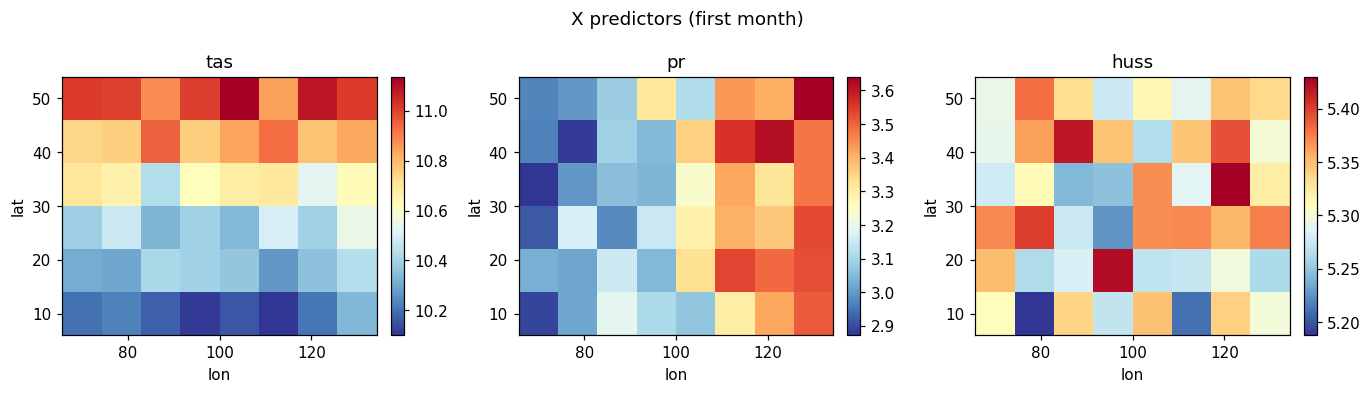

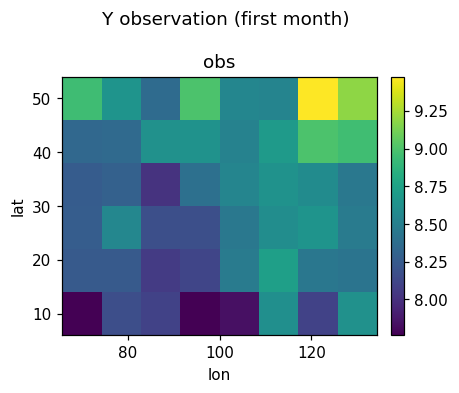

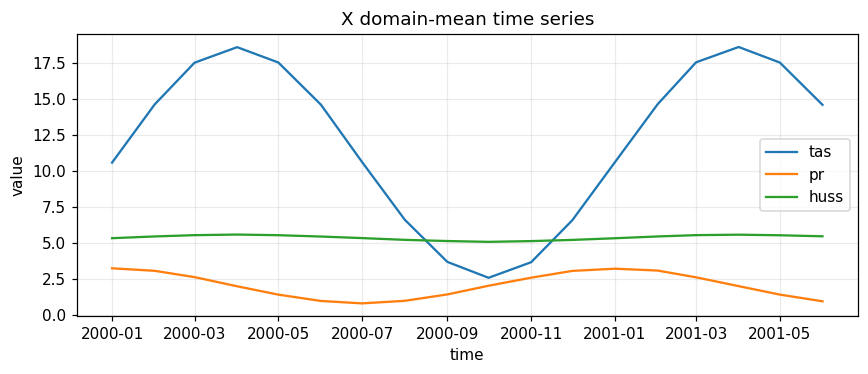

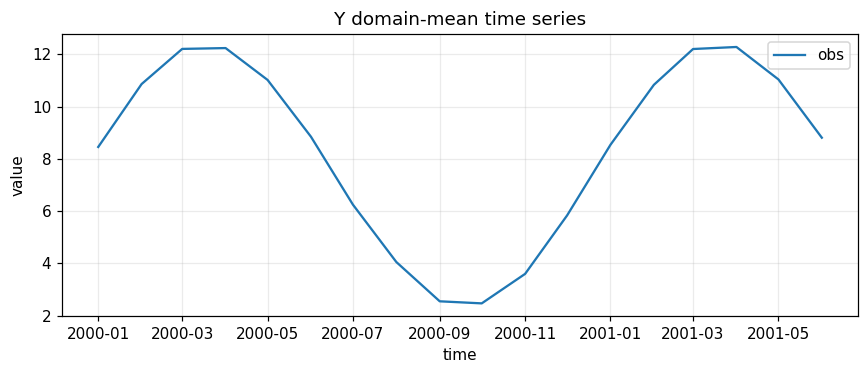

In [5]:
x_raw, y_raw = make_synthetic_cubes(n_time=18, n_lat=6, n_lon=8, seed=SEED)
print(x_raw)
print(y_raw)
plot_cube_maps(x_raw, time_index=0, title="X predictors (first month)")
plot_cube_maps(y_raw, time_index=0, cmap="viridis", title="Y observation (first month)")
plot_spatial_mean_timeseries(x_raw, title="X domain-mean time series")
plot_spatial_mean_timeseries(y_raw, title="Y domain-mean time series")
plt.show()

## 2. 预处理（去趋势 / 去季节等）

本 demo 默认关闭，但画出处理后的 Y，便于你改配置后对比。可把 `deseasonalize` 改成 `True` 再跑本格。

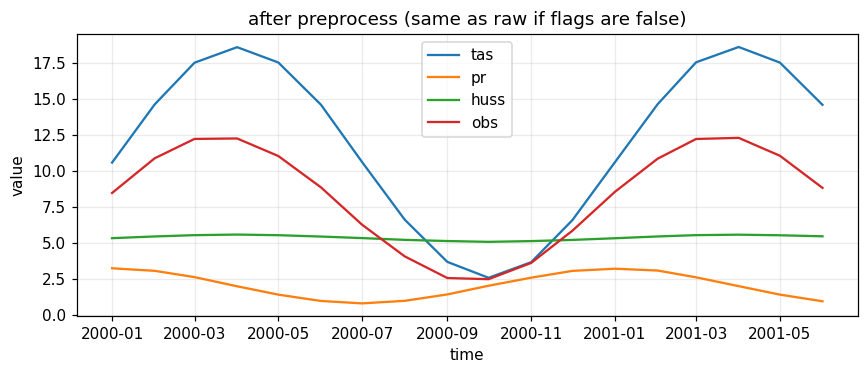

In [6]:
x = preprocess_dataset(x_raw, cfg.raw["preprocess"]["x"])
y = preprocess_dataset(y_raw, cfg.raw["preprocess"]["y"])
plot_spatial_mean_timeseries(xr.merge([x, y]), title="after preprocess (same as raw if flags are false)")
plt.show()

## 3. 构造 X：原始值 + lag

`mode=lag` 会生成 `tas_lag1` 等，并丢掉最前面无法对齐 lag 的时间步。Y 同步裁到同一时间。

transform meta: {'mode': 'lag', 'lags': [1], 'feature_pca': None, 'pca_whiten': False}
X variables: ['tas', 'pr', 'huss', 'tas_lag1', 'pr_lag1', 'huss_lag1']
time steps: 18 → 17


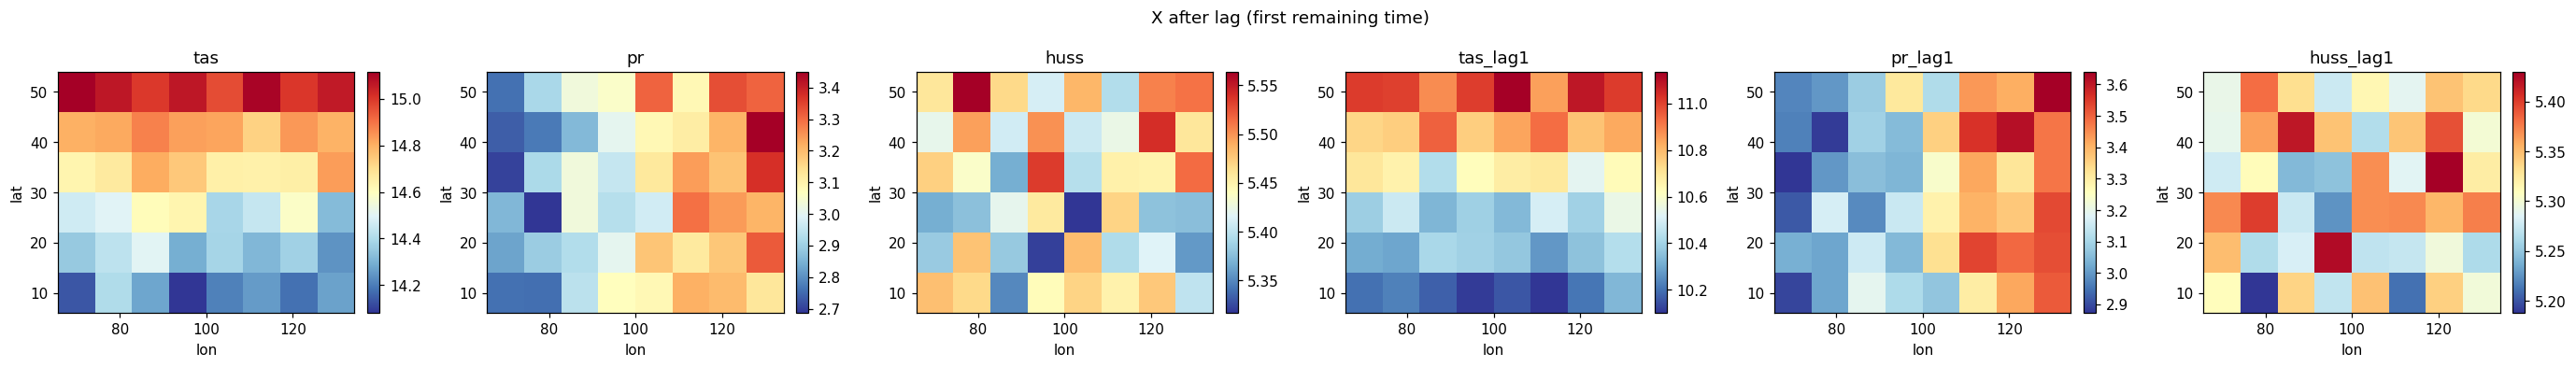

In [7]:
xt_cfg = cfg.raw["x_transform"]
x_feat, meta = build_x_features(x, mode=xt_cfg["mode"], lags=xt_cfg["lags"])
y_feat, x_feat = xr.align(y, x_feat, join="inner")
print("transform meta:", meta)
print("X variables:", list(x_feat.data_vars))
print("time steps:", int(x_raw.sizes["time"]), "→", int(x_feat.sizes["time"]))
plot_cube_maps(x_feat, time_index=0, title="X after lag (first remaining time)")
plt.show()

## 4. 摊平为样本表（X、Y 一一对应）

每个有效 `(time, lat, lon)` 是一行。直方图检查 Y 和主要预测因子的分布。

        time   lat         lon        tas        pr      huss   tas_lag1  \
0 2000-02-01  10.0   70.000000  14.135853  2.757954  5.481598  10.200123   
1 2000-02-01  10.0   78.571429  14.400042  2.757678  5.467485  10.229875   
2 2000-02-01  10.0   87.142857  14.276226  2.938373  5.350110  10.172586   
3 2000-02-01  10.0   95.714286  14.080071  3.069970  5.442752  10.110941   
4 2000-02-01  10.0  104.285714  14.207452  3.085664  5.471070  10.154533   

    pr_lag1  huss_lag1        obs  
0  2.891518   5.310519  10.398486  
1  3.018337   5.187993  10.535861  
2  3.192474   5.338747  10.895822  
3  3.108230   5.270207  10.576681  
4  3.068725   5.348204  10.854275  
n_samples: 816 n_features: 6


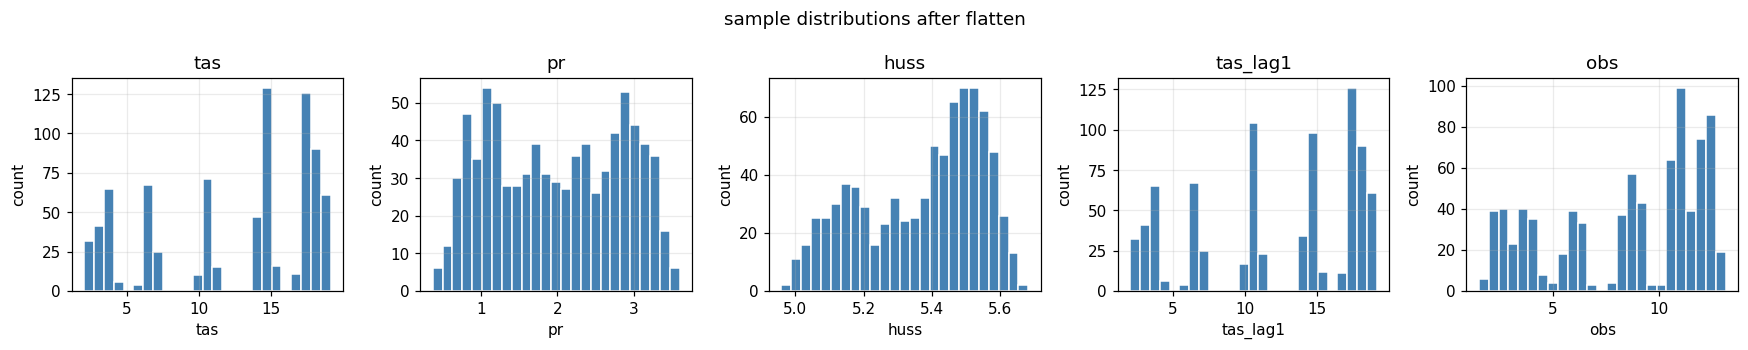

In [8]:
table = cube_to_table(x_feat, y_feat)
frame = table.to_frame()
print(frame.head())
print("n_samples:", table.n_samples, "n_features:", len(table.feature_names))
plot_histograms(frame, table.feature_names[:4] + [table.y_name], title="sample distributions after flatten")
plt.show()

## 5. 训练 / 测试划分（时间切分）

左图/右图：训练与测试样本的空间覆盖；下一图：时间轴上哪些月份进训练、哪些进测试。

method: time train: 624 test: 192


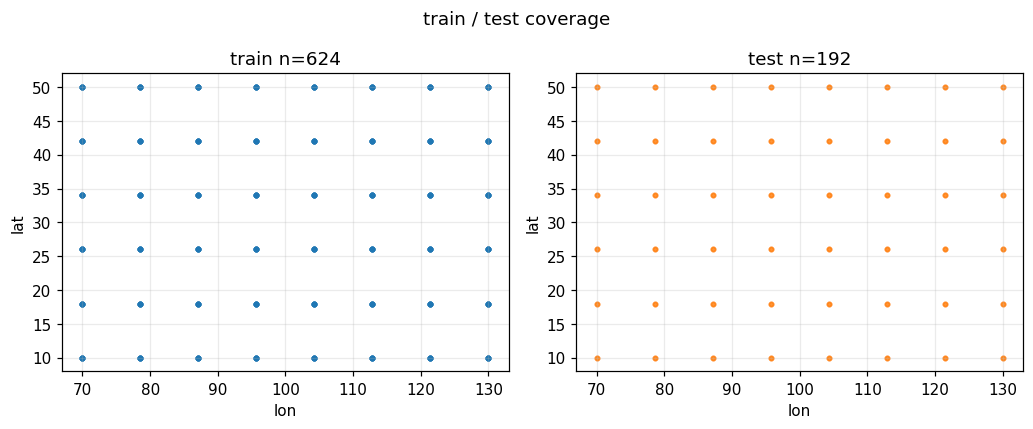

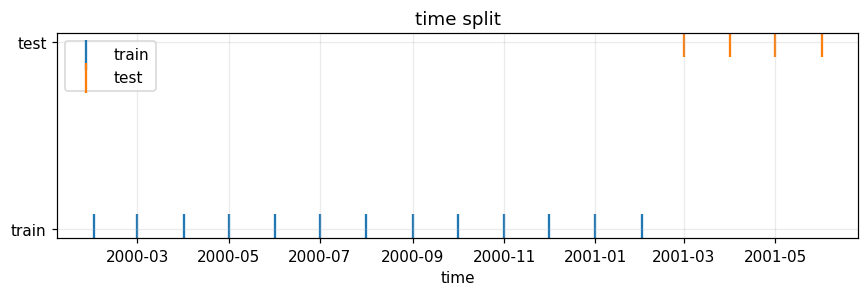

In [9]:
split = split_table(table, cfg.raw["split"], seed=SEED)
print("method:", split.method, "train:", split.train.n_samples, "test:", split.test.n_samples)
plot_split_coverage(split.train.index, split.test.index)
plot_split_time(split.train.index, split.test.index)
plt.show()

## 6. 特征选择（共线性 + 成对重要性）

对比选择前后的相关矩阵，以及留下的变量。

kept: ['huss', 'tas_lag1', 'pr_lag1']
history: [{'method': 'collinearity', 'kept': ['huss', 'tas_lag1', 'pr_lag1', 'huss_lag1']}, {'method': 'pairwise_importance', 'kept': ['huss', 'tas_lag1', 'pr_lag1']}]


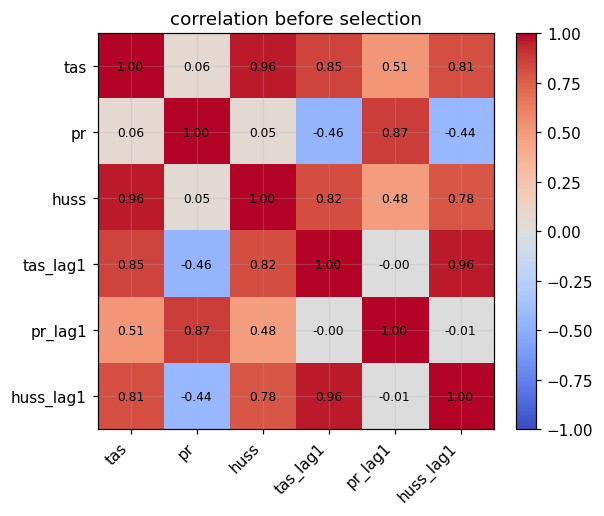

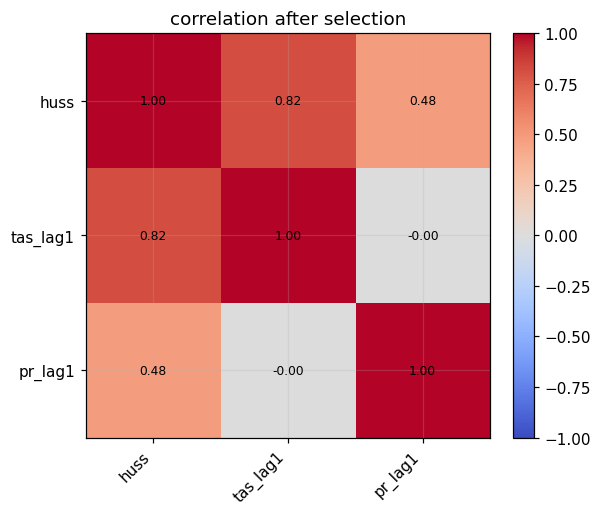

In [10]:
plot_correlation(split.train.X, split.train.feature_names, title="correlation before selection")
train = select_features(split.train, cfg.raw["feature_selection"], seed=SEED)
test = split.test.select_columns(train.feature_names)
print("kept:", train.feature_names)
print("history:", train.extras.get("selection_history"))
plot_correlation(train.X, train.feature_names, title="correlation after selection")
plt.show()

## 7. 训练集采样（FSCS 特征空间覆盖）

灰色：全部训练格点；红色：被抽中用于拟合的子集。


Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md



sampled: 400 / 624


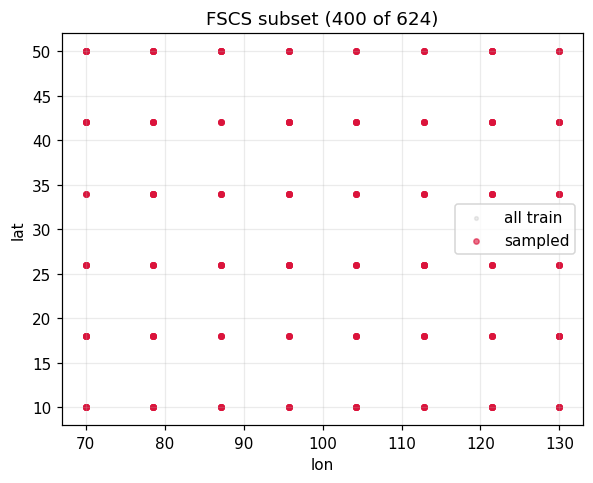

In [11]:
samp = cfg.raw["sampling"]
idx = sample_train(
    train.X,
    train.y,
    method=samp["method"],
    n_samples=samp["n_samples"],
    seed=SEED,
    lat=np.asarray(train.index.get_level_values("lat")),
    lon=np.asarray(train.index.get_level_values("lon")),
)
train_s = train.take(idx)
print("sampled:", train_s.n_samples, "/", train.n_samples)
plot_sampling_map(train.index, train_s.index, title=f"FSCS subset ({train_s.n_samples} of {train.n_samples})")
plt.show()

## 8. 建模与预测

散点：测试集观测 vs 预测。地图：时间平均的观测、预测、误差（可还原回 cube）。

,value
n,192.000000
r2,0.935770
rmse,0.365071
mae,0.288941
bias,-0.043177
ubrmse,0.362509
nse,0.935770
kge,0.895053
pearson_r,0.970420
mape,0.026996


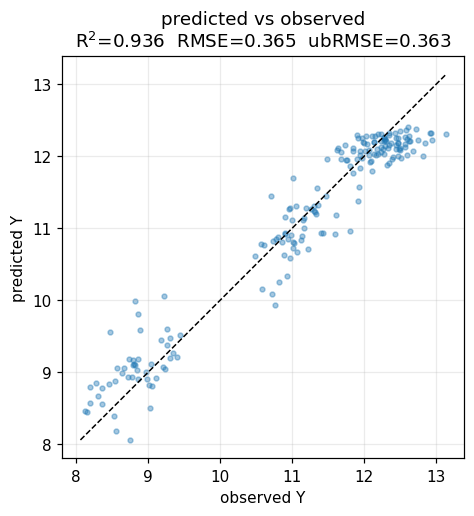

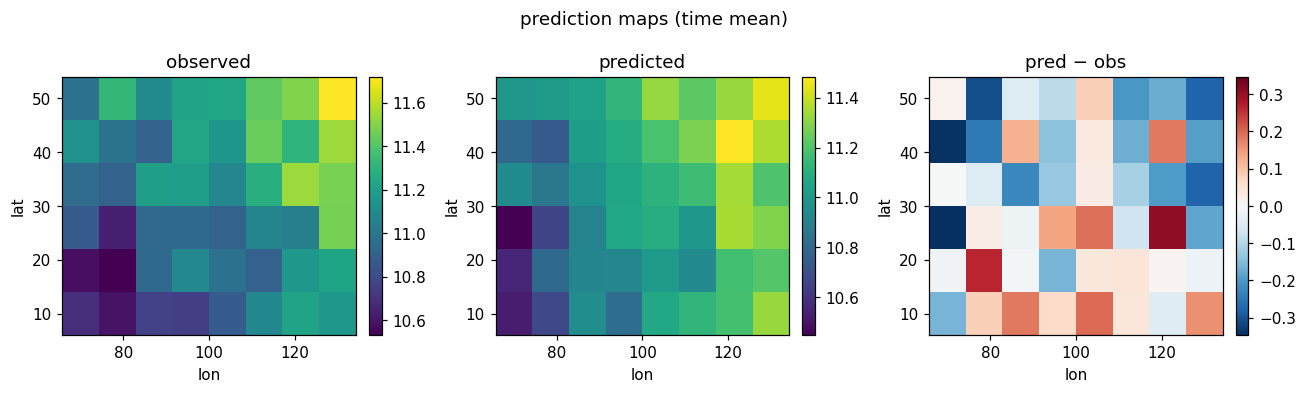

In [12]:
model = build_model(cfg.raw["model"]["name"], cfg.raw["model"]["params"], seed=SEED)
model.fit(train_s.X, train_s.y)
pred = model.predict(test.X)
metrics = regression_metrics(test.y, pred)
metrics.update(n_train=int(train_s.n_samples), n_test=int(test.n_samples), n_features=len(train.feature_names))
display(pd.Series(metrics).to_frame("value"))

template = table.extras["template"]
test.extras["template"] = template
pred_cube = reconstruct_prediction(pred, test)
obs_cube = reconstruct_prediction(test.y, test, name="obs")

plot_pred_scatter(test.y, pred, metrics)
plot_error_map(obs_cube, pred_cube)
plt.show()

## 9. 解释：树重要性 + 置换重要性

,feature,importance
0,huss,0.478906
1,tas_lag1,0.268853
2,pr_lag1,0.252241


,feature,importance,std
2,pr_lag1,1.798834,0.039150
1,tas_lag1,0.182108,0.002415
0,huss,0.057747,0.010362


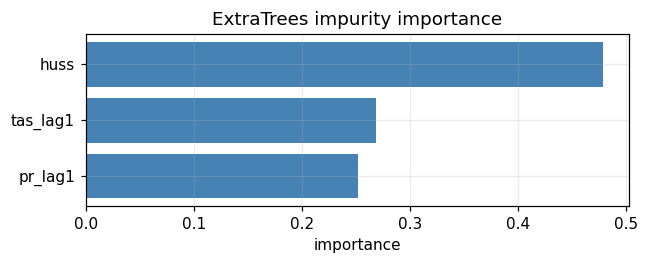

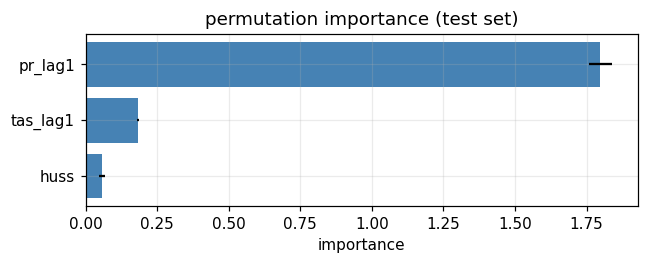

In [13]:
imp = model_importance(model, train.feature_names)
perm = permutation_scores(
    model, test.X, test.y, train.feature_names,
    n_repeats=cfg.raw["explain"]["permutation_n_repeats"], seed=SEED,
)
display(imp)
display(perm)
plot_importance_bars(imp, title="ExtraTrees impurity importance")
plot_importance_bars(perm, title="permutation importance (test set)")
plt.show()

## 10. SHAP（局部贡献）并还原为 cube

摘要图：每个样本一个点，颜色是特征值高低。地图：SHAP 写回 `(time, lat, lon)`，可看贡献的空间结构。

SHAP method: treeshap explained samples: 192


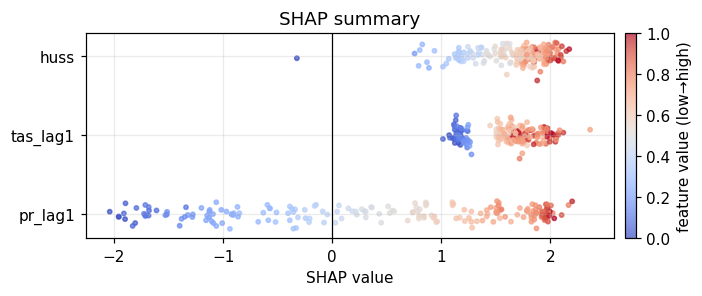

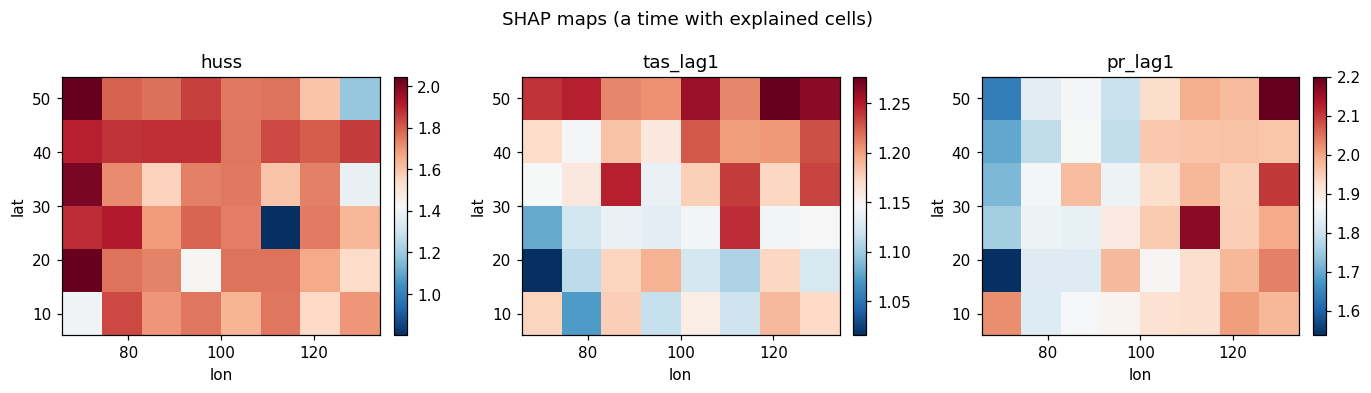

In [14]:
shap_cfg = cfg.raw["explain"]["shap"]
shap_res = compute_shap(
    model,
    test,
    method=shap_cfg["method"],
    max_samples=shap_cfg["max_samples"],
    background_size=shap_cfg["background_size"],
    seed=SEED,
    background=train_s.X,
)
shap_cube = shap_to_cube(shap_res, test)
print("SHAP method:", shap_res.method, "explained samples:", len(shap_res.sample_positions))
xs = test.X[shap_res.sample_positions]
plot_shap_summary(shap_res.values, xs, shap_res.feature_names)
cover = shap_cube.to_array(dim="feature").notnull().any("feature").sum(("lat", "lon"))
t_idx = int(cover.argmax("time"))
plot_shap_maps(shap_cube, time_index=t_idx, title="SHAP maps (a time with explained cells)")
plt.show()

## 11. ALE 与 ICE + PDP

ALE：相关特征下更稳的平均效应。ICE 细线是单个样本曲线，红线是 PDP 平均。

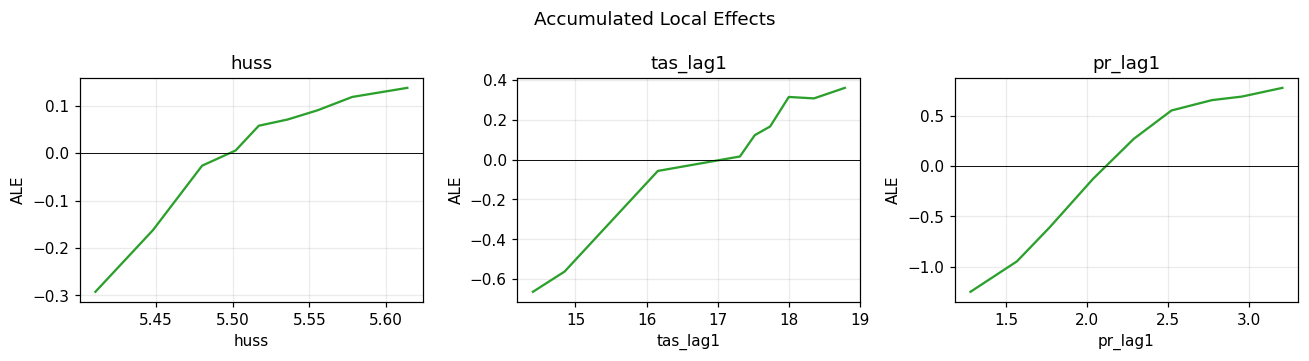

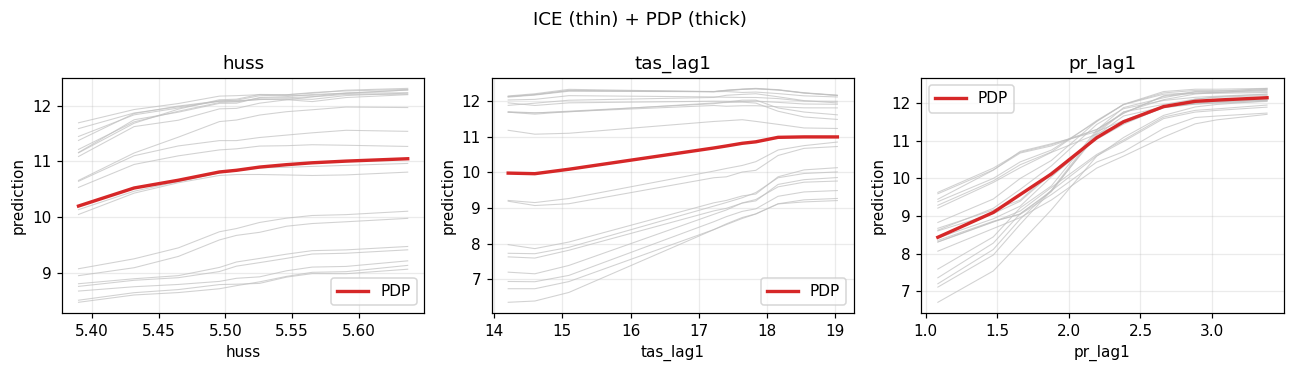

In [15]:
ale = ale_1d(model, test.X, train.feature_names, n_grid=cfg.raw["explain"]["pdp_grid"])
ice = ice_pdp(
    model, test.X, train.feature_names,
    n_grid=cfg.raw["explain"]["pdp_grid"],
    ice_n_samples=cfg.raw["explain"]["ice_n_samples"],
    seed=SEED,
)
plot_ale(ale)
plot_ice_pdp(ice)
plt.show()

## 12. 保存结果（可选）

In [ ]:
out = Path("outputs/demo_notebook")
out.mkdir(parents=True, exist_ok=True)
pd.Series(metrics).to_csv(out / "metrics.csv")
pred_cube.to_netcdf(out / "prediction.nc")
shap_cube.to_netcdf(out / "shap.nc")
imp.to_csv(out / "rf_importance.csv", index=False)
perm.to_csv(out / "permutation_importance.csv", index=False)
print("saved to", out.resolve())